In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
from PIL import Image
from tqdm import tqdm
Image.MAX_IMAGE_PIXELS = None  # 取消限制

# ---------------------------
# 读取蛋白编码基因列表（用于过滤）
# ---------------------------
df_gene = pd.read_csv("protein_coding_hg38.txt", header=None, names=["id", "name"])
df_gene = df_gene.dropna(subset=["name"])
valid_genes = set(df_gene["name"].str.upper())

# ---------------------------
# 读取鼠-人映射表
# ---------------------------
df_map = pd.read_csv("hg38_human_mouse.txt")  # 这个是你给的 txt
df_map = df_map.dropna(subset=["Mouse gene name", "Gene name"])
mouse2human = dict(
    zip(
        df_map["Mouse gene name"].str.lower(),  # 小鼠基因名转小写
        df_map["Gene name"].str.upper()         # 人类基因名全大写
    )
)

# ---------------------------
# tokenize 函数（按表达值高低排序，生成 top_k token）
# ---------------------------
def tokenize_spots(ad_ge, top_k=2048, label_mode="threshold", valid_gene_names=None, add_labels=True):
    assert label_mode in ["percentile", "zscore", "threshold"]

    X = ad_ge.X  # shape: (n_spots, n_genes)
    gene_names = np.array([g.upper() for g in ad_ge.var_names])  # 保证大写

    # 过滤掉不在 valid_gene_names 的基因
    if valid_gene_names is not None:
        valid_mask = np.isin(gene_names, list(valid_gene_names))
        X = X[:, valid_mask]
        gene_names = gene_names[valid_mask]

    # H/M/L 标签函数（只用于 token 标记，不是 label）
    if label_mode == "percentile":
        low, high = np.percentile(X, [33, 66])
        def label_func(vals):
            return np.where(vals > high, "(H)", np.where(vals < low, "(L)", "(M)"))
    elif label_mode == "zscore":
        mean, std = np.mean(X), np.std(X)
        def label_func(vals):
            z = (vals - mean) / std
            return np.where(z > 1, "(H)", np.where(z < -1, "(L)", "(M)"))
    else:  # threshold
        def label_func(vals):
            return np.where(vals >= 3.0, "(H)", np.where(vals < 2.0, "(L)", "(M)"))

    # 每个 spot 按表达值从大到小选 top_k 基因并附标签
    tokens_list = []
    for i in range(X.shape[0]):
        expr = X[i, :]
        top_idx = np.argsort(-expr)[:top_k]
        top_genes = gene_names[top_idx]
        top_exprs = expr[top_idx]
        if add_labels:
            top_tags = label_func(top_exprs)
            top_tokens = [f"{g}{t}" for g, t in zip(top_genes, top_tags)]
        else:
            top_tokens = list(top_genes)
        tokens_list.append(top_tokens)

    return tokens_list

# ---------------------------
# 从 HE 图像提取 32x32 patch
# ---------------------------
def extract_spot_patches_exact32(adata, image_path, channel_first=True, normalize=True):
    img = Image.open(image_path).convert("RGB")
    spatial_coords = adata.obsm["spatial"]
    patch_size = 32
    patches = []

    for i in range(spatial_coords.shape[0]):
        x, y = spatial_coords[i]
        left   = int(x - patch_size / 2)
        upper  = int(y - patch_size / 2)
        right  = left + patch_size
        lower  = upper + patch_size

        patch = img.crop((left, upper, right, lower)) 
        patch_np = np.array(patch).astype(np.float32)

        if normalize:
            patch_np /= 255.0  # → [0,1]

        if channel_first:
            patch_np = patch_np.transpose(2, 0, 1)  # → [C,32,32]

        patches.append(patch_np)

    return np.stack(patches)  # → shape: [N, C, 32, 32]

# ---------------------------
# 处理一个 count_df（检测是否鼠类并映射）
# ---------------------------
def preprocess_gene_matrix(count_df):
    """
    处理 count_df：
    - 如果是小鼠 → 仅保留能映射到人类的基因，否则返回 None
    - 如果是人类 → 全部大写
    """
    gene_names = count_df.columns.tolist()

    # 判断是否是小鼠（看第一个基因是否包含小写）
    if any(c.islower() for c in gene_names[0]):
        # 小写化全部列名
        gene_names_lower = [g.lower() for g in gene_names]

        # 只保留能映射的鼠基因
        available_mouse_genes = [g for g in gene_names_lower if g in mouse2human]

        if len(available_mouse_genes) == 0:
            # ❌ 没有能映射的鼠基因 → 返回 None，让外层跳过
            return None

        # 只保留能映射的列
        count_df = count_df.loc[:, [g for g in gene_names if g.lower() in available_mouse_genes]]

        # 映射到人类基因名
        mapped_names = [mouse2human[g.lower()] for g in count_df.columns]
        # 过滤掉映射后为空的
        keep_cols, keep_names = [], []
        for col, new_name in zip(count_df.columns, mapped_names):
            if new_name and isinstance(new_name, str) and len(new_name.strip()) > 0:
                keep_cols.append(col)
                keep_names.append(new_name)
        count_df = count_df.loc[:, keep_cols]
        count_df.columns = keep_names

        if count_df.shape[1] == 0:
            # 如果过滤后没有列，直接返回 None 跳过
            return None

    else:
        # 人类 → 大写
        count_df.columns = [g.upper() for g in gene_names]

    return count_df

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
from PIL import Image
from tqdm import tqdm
Image.MAX_IMAGE_PIXELS = None  # 取消限制

# ---------------------------
# 读取蛋白编码基因列表（用于过滤）
# ---------------------------
df_gene = pd.read_csv("protein_coding_hg38.txt", header=None, names=["id", "name"])
df_gene = df_gene.dropna(subset=["name"])
valid_genes = set(df_gene["name"].str.upper())

# ---------------------------
# 读取鼠-人映射表
# ---------------------------
df_map = pd.read_csv("hg38_human_mouse.txt")  # 这个是你给的 txt
df_map = df_map.dropna(subset=["Mouse gene name", "Gene name"])
mouse2human = dict(
    zip(
        df_map["Mouse gene name"].str.lower(),  # 小鼠基因名转小写
        df_map["Gene name"].str.upper()         # 人类基因名全大写
    )
)

# ---------------------------
# tokenize 函数（按表达值高低排序，生成 top_k token）
# ---------------------------
def tokenize_spots(ad_ge, top_k=2048, label_mode="threshold", valid_gene_names=None, add_labels=True):
    assert label_mode in ["percentile", "zscore", "threshold"]

    X = ad_ge.X  # shape: (n_spots, n_genes)
    gene_names = np.array([g.upper() for g in ad_ge.var_names])  # 保证大写

    # 过滤掉不在 valid_gene_names 的基因
    if valid_gene_names is not None:
        valid_mask = np.isin(gene_names, list(valid_gene_names))
        X = X[:, valid_mask]
        gene_names = gene_names[valid_mask]

    # H/M/L 标签函数（只用于 token 标记，不是 label）
    if label_mode == "percentile":
        low, high = np.percentile(X, [33, 66])
        def label_func(vals):
            return np.where(vals > high, "(H)", np.where(vals < low, "(L)", "(M)"))
    elif label_mode == "zscore":
        mean, std = np.mean(X), np.std(X)
        def label_func(vals):
            z = (vals - mean) / std
            return np.where(z > 1, "(H)", np.where(z < -1, "(L)", "(M)"))
    else:  # threshold
        def label_func(vals):
            return np.where(vals >= 3.0, "(H)", np.where(vals < 2.0, "(L)", "(M)"))

    # 每个 spot 按表达值从大到小选 top_k 基因并附标签
    tokens_list = []
    for i in range(X.shape[0]):
        expr = X[i, :]
        top_idx = np.argsort(-expr)[:top_k]
        top_genes = gene_names[top_idx]
        top_exprs = expr[top_idx]
        if add_labels:
            top_tags = label_func(top_exprs)
            top_tokens = [f"{g}{t}" for g, t in zip(top_genes, top_tags)]
        else:
            top_tokens = list(top_genes)
        tokens_list.append(top_tokens)

    return tokens_list

# ---------------------------
# 从 HE 图像提取 32x32 patch
# ---------------------------
def extract_spot_patches_exact32(adata, image_path, channel_first=True, normalize=True):
    img = Image.open(image_path).convert("RGB")
    spatial_coords = adata.obsm["spatial"]
    patch_size = 32
    patches = []

    for i in range(spatial_coords.shape[0]):
        x, y = spatial_coords[i]
        left   = int(x - patch_size / 2)
        upper  = int(y - patch_size / 2)
        right  = left + patch_size
        lower  = upper + patch_size

        patch = img.crop((left, upper, right, lower)) 
        patch_np = np.array(patch).astype(np.float32)

        if normalize:
            patch_np /= 255.0  # → [0,1]

        if channel_first:
            patch_np = patch_np.transpose(2, 0, 1)  # → [C,32,32]

        patches.append(patch_np)

    return np.stack(patches)  # → shape: [N, C, 32, 32]

# ---------------------------
# 处理一个 count_df（检测是否鼠类并映射）
# ---------------------------
def preprocess_gene_matrix(count_df):
    """
    处理 count_df：
    - 如果是小鼠 → 仅保留能映射到人类的基因，否则返回 None
    - 如果是人类 → 全部大写
    """
    gene_names = count_df.columns.tolist()

    # 判断是否是小鼠（看第一个基因是否包含小写）
    if any(c.islower() for c in gene_names[0]):
        # 小写化全部列名
        gene_names_lower = [g.lower() for g in gene_names]

        # 只保留能映射的鼠基因
        available_mouse_genes = [g for g in gene_names_lower if g in mouse2human]

        if len(available_mouse_genes) == 0:
            # ❌ 没有能映射的鼠基因 → 返回 None，让外层跳过
            return None

        # 只保留能映射的列
        count_df = count_df.loc[:, [g for g in gene_names if g.lower() in available_mouse_genes]]

        # 映射到人类基因名
        mapped_names = [mouse2human[g.lower()] for g in count_df.columns]
        # 过滤掉映射后为空的
        keep_cols, keep_names = [], []
        for col, new_name in zip(count_df.columns, mapped_names):
            if new_name and isinstance(new_name, str) and len(new_name.strip()) > 0:
                keep_cols.append(col)
                keep_names.append(new_name)
        count_df = count_df.loc[:, keep_cols]
        count_df.columns = keep_names

        if count_df.shape[1] == 0:
            # 如果过滤后没有列，直接返回 None 跳过
            return None

    else:
        # 人类 → 大写
        count_df.columns = [g.upper() for g in gene_names]

    return count_df



# ---------------------------
# 核心批量处理函数
# ---------------------------
def process_all_samples(base_dir, output_dir):
    coord_dir = os.path.join(base_dir, "coord")
    gene_dir = os.path.join(base_dir, "gene_exp")
    img_dir = os.path.join(base_dir, "image")

    coord_files = glob.glob(os.path.join(coord_dir, "*_coord.csv"))
    sample_prefixes = [os.path.basename(f).replace("_coord.csv", "") for f in coord_files]

    os.makedirs(output_dir, exist_ok=True)

    for prefix in tqdm(sample_prefixes, desc="Processing samples"):
        save_path = os.path.join(output_dir, f"{prefix}.npz")
        
        # 如果 npz 已存在 → 跳过
        if os.path.exists(save_path):
            continue

        coord_path = os.path.join(coord_dir, f"{prefix}_coord.csv")
        gene_path  = os.path.join(gene_dir,  f"{prefix}_count.csv")
        img_path   = os.path.join(img_dir,   f"{prefix}.png")

        # 检查文件是否齐全
        if not (os.path.exists(coord_path) and os.path.exists(gene_path) and os.path.exists(img_path)):
            print(f"⚠️ 缺少文件，跳过 {prefix}")
            continue

        # ---- 1. 读取 CSV ----
        count_df = pd.read_csv(gene_path, index_col=0)
        coord_df = pd.read_csv(coord_path, index_col=0)

        # ---- 1.5 鼠类 → 转人类基因 ----
        count_df = preprocess_gene_matrix(count_df)
        if count_df is None or count_df.shape[1] == 0:
            # ❌ 没有任何基因可用 → 跳过
            print(f"⚠️ 无法映射，跳过 {prefix}")
            continue

        # ---- 2. 构造 AnnData ----
        adata = ad.AnnData(
            X = count_df.values,
            obs = pd.DataFrame(index = count_df.index),
            var = pd.DataFrame(index = count_df.columns)
        )
        adata.obsm["spatial"] = coord_df.loc[adata.obs.index, ["xaxis", "yaxis"]].values

        # ---- 3. 标准预处理 ----
        sc.pp.filter_cells(adata, min_genes=200)
        sc.pp.filter_genes(adata, min_cells=3)
        sc.pp.normalize_total(adata, target_sum=1e4)
        sc.pp.log1p(adata)

        # ---- 4. 生成 tokens ----
        tokens = tokenize_spots(
            ad_ge=adata,
            top_k=2048,
            label_mode="threshold",
            valid_gene_names=valid_genes,
            add_labels=False
        )

        # ---- 5. 提取 patch ----
        patches = extract_spot_patches_exact32(adata, img_path)

        # ---- 6. 保存 npz ----
        spot_ids = adata.obs.index.values
        coords = adata.obsm["spatial"]

        np.savez_compressed(
            save_path,
            patch=patches,
            tokens=np.array(tokens, dtype=object),
            spot_ids=spot_ids,
            coords=coords
        )

In [ ]:
process_all_samples(
    base_dir="./STimage-1K4M/breast",        # 输入数据根目录
    output_dir="./npz_data/breast_data"   # 每个样本单独保存 npz
)

# 下面是加注释的

In [2]:
import os
import glob
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
from PIL import Image
from tqdm import tqdm
Image.MAX_IMAGE_PIXELS = None  # 取消限制

# ---------------------------
# 读取蛋白编码基因列表（用于过滤）
# ---------------------------
df_gene = pd.read_csv("protein_coding_hg38.txt", header=None, names=["id", "name"])
df_gene = df_gene.dropna(subset=["name"])
valid_genes = set(df_gene["name"].str.upper())

# ---------------------------
# 读取鼠-人映射表
# ---------------------------
df_map = pd.read_csv("hg38_human_mouse.txt")  # 这个是你给的 txt
df_map = df_map.dropna(subset=["Mouse gene name", "Gene name"])
mouse2human = dict(
    zip(
        df_map["Mouse gene name"].str.lower(),  # 小鼠基因名转小写
        df_map["Gene name"].str.upper()         # 人类基因名全大写
    )
)

# ---------------------------
# tokenize 函数（按表达值高低排序，生成 top_k token）
# ---------------------------
def tokenize_spots(ad_ge, top_k=2048, label_mode="threshold", valid_gene_names=None, add_labels=True):
    assert label_mode in ["percentile", "zscore", "threshold"]

    X = ad_ge.X  # shape: (n_spots, n_genes)
    gene_names = np.array([g.upper() for g in ad_ge.var_names])  # 保证大写

    # 过滤掉不在 valid_gene_names 的基因
    if valid_gene_names is not None:
        valid_mask = np.isin(gene_names, list(valid_gene_names))
        X = X[:, valid_mask]
        gene_names = gene_names[valid_mask]

    # H/M/L 标签函数（只用于 token 标记，不是 label）
    if label_mode == "percentile":
        low, high = np.percentile(X, [33, 66])
        def label_func(vals):
            return np.where(vals > high, "(H)", np.where(vals < low, "(L)", "(M)"))
    elif label_mode == "zscore":
        mean, std = np.mean(X), np.std(X)
        def label_func(vals):
            z = (vals - mean) / std
            return np.where(z > 1, "(H)", np.where(z < -1, "(L)", "(M)"))
    else:  # threshold
        def label_func(vals):
            return np.where(vals >= 3.0, "(H)", np.where(vals < 2.0, "(L)", "(M)"))

    # 每个 spot 按表达值从大到小选 top_k 基因并附标签
    tokens_list = []
    for i in range(X.shape[0]):
        expr = X[i, :]
        top_idx = np.argsort(-expr)[:top_k]
        top_genes = gene_names[top_idx]
        top_exprs = expr[top_idx]
        if add_labels:
            top_tags = label_func(top_exprs)
            top_tokens = [f"{g}{t}" for g, t in zip(top_genes, top_tags)]
        else:
            top_tokens = list(top_genes)
        tokens_list.append(top_tokens)

    return tokens_list

# ---------------------------
# 从 HE 图像提取 32x32 patch
# ---------------------------
def extract_spot_patches_exact32(adata, image_path, channel_first=True, normalize=True):
    img = Image.open(image_path).convert("RGB")
    spatial_coords = adata.obsm["spatial"]
    patch_size = 32
    patches = []

    for i in range(spatial_coords.shape[0]):
        x, y = spatial_coords[i]
        left   = int(x - patch_size / 2)
        upper  = int(y - patch_size / 2)
        right  = left + patch_size
        lower  = upper + patch_size

        patch = img.crop((left, upper, right, lower)) 
        patch_np = np.array(patch).astype(np.float32)

        if normalize:
            patch_np /= 255.0  # → [0,1]

        if channel_first:
            patch_np = patch_np.transpose(2, 0, 1)  # → [C,32,32]

        patches.append(patch_np)

    return np.stack(patches)  # → shape: [N, C, 32, 32]

# ---------------------------
# 处理一个 count_df（检测是否鼠类并映射）
# ---------------------------
def preprocess_gene_matrix(count_df):
    """
    处理 count_df：
    - 如果是小鼠 → 仅保留能映射到人类的基因，否则返回 None
    - 如果是人类 → 全部大写
    """
    gene_names = count_df.columns.tolist()

    # 判断是否是小鼠（看第一个基因是否包含小写）
    if any(c.islower() for c in gene_names[0]):
        # 小写化全部列名
        gene_names_lower = [g.lower() for g in gene_names]

        # 只保留能映射的鼠基因
        available_mouse_genes = [g for g in gene_names_lower if g in mouse2human]

        if len(available_mouse_genes) == 0:
            # ❌ 没有能映射的鼠基因 → 返回 None，让外层跳过
            return None

        # 只保留能映射的列
        count_df = count_df.loc[:, [g for g in gene_names if g.lower() in available_mouse_genes]]

        # 映射到人类基因名
        mapped_names = [mouse2human[g.lower()] for g in count_df.columns]
        # 过滤掉映射后为空的
        keep_cols, keep_names = [], []
        for col, new_name in zip(count_df.columns, mapped_names):
            if new_name and isinstance(new_name, str) and len(new_name.strip()) > 0:
                keep_cols.append(col)
                keep_names.append(new_name)
        count_df = count_df.loc[:, keep_cols]
        count_df.columns = keep_names

        if count_df.shape[1] == 0:
            # 如果过滤后没有列，直接返回 None 跳过
            return None

    else:
        # 人类 → 大写
        count_df.columns = [g.upper() for g in gene_names]

    return count_df

/softwares/miniconda3/envs/dl/lib/python3.10/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


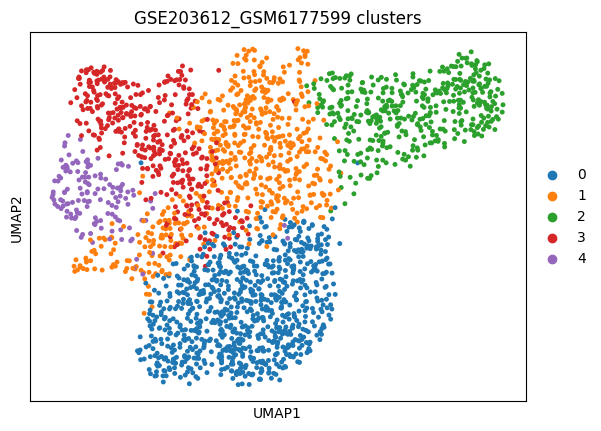

/softwares/miniconda3/envs/dl/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/softwares/miniconda3/envs/dl/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/softwares/miniconda3/envs/dl/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/softwares/miniconda3/envs/dl/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/softwares/miniconda3/envs/dl/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchange

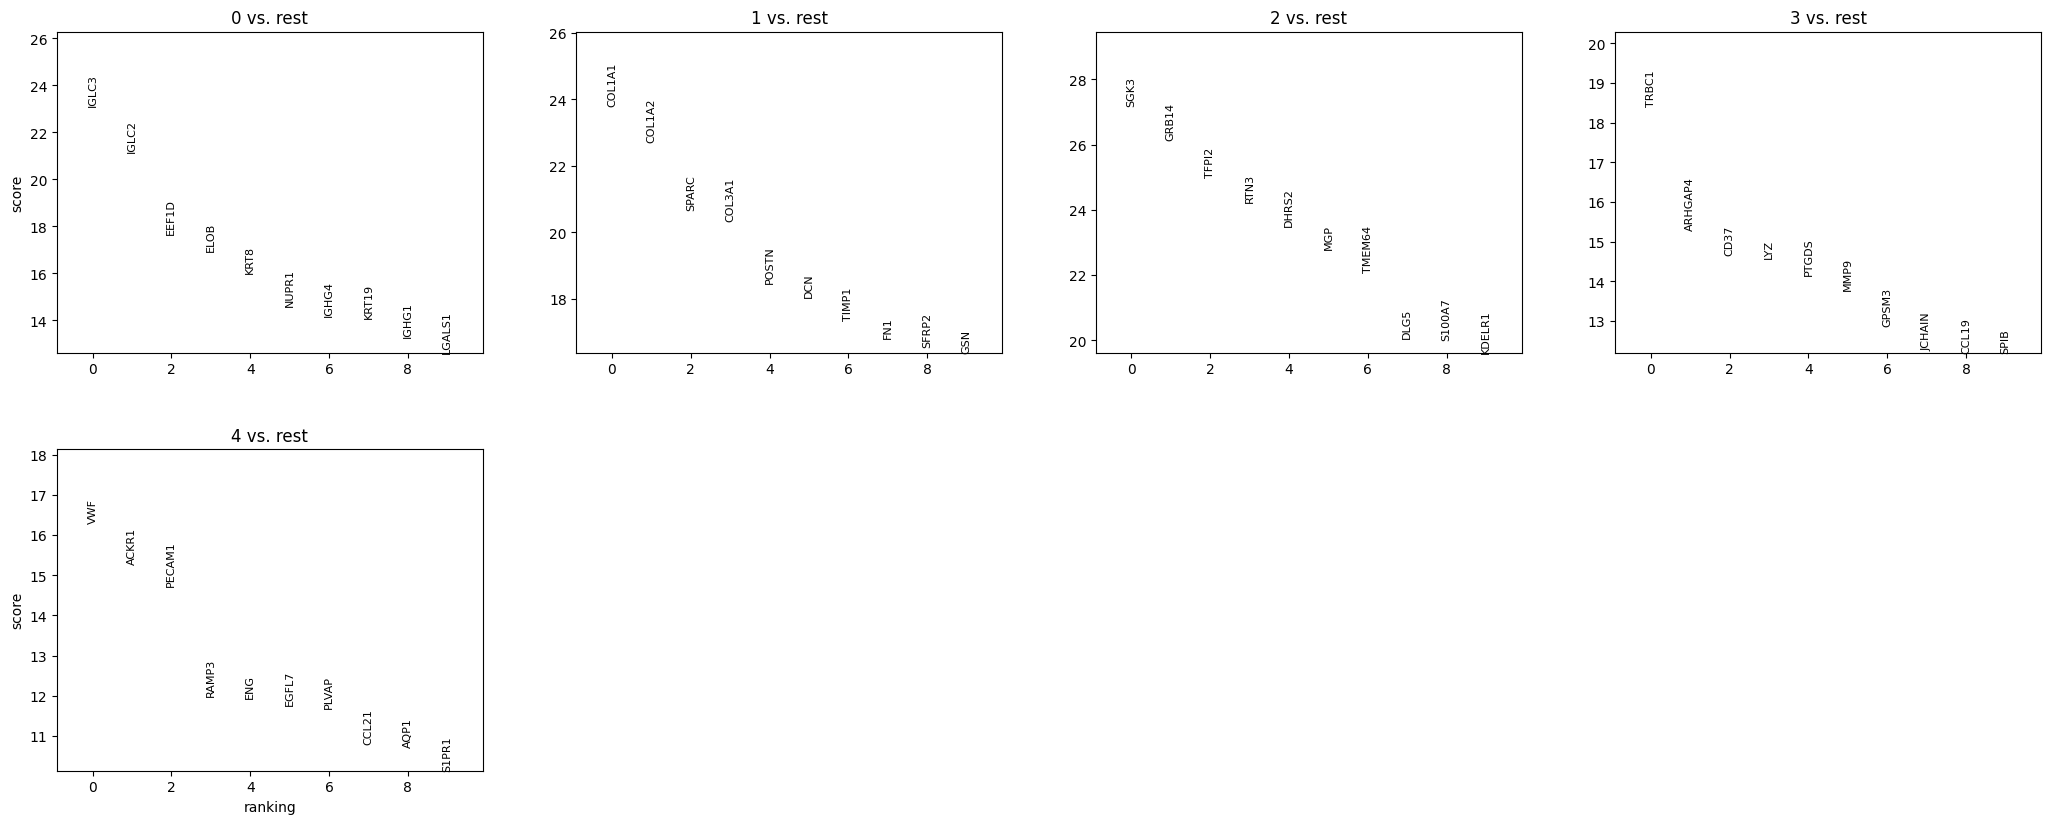

/tmp/ipykernel_2580752/4273625509.py:66: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color='leiden', spot_size=20, title=f"{sample_name} spatial clusters")


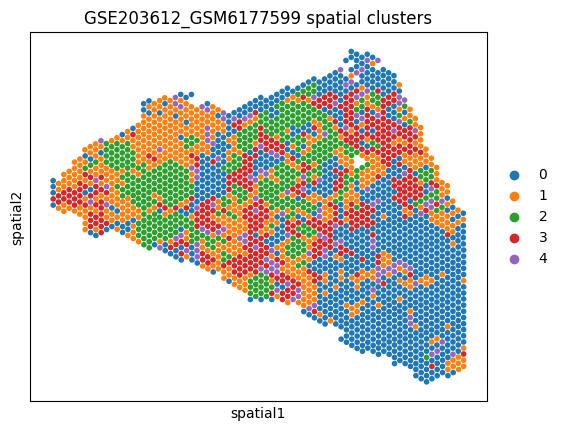

=== Cluster 0 ===
  group   names     scores  logfoldchanges          pvals      pvals_adj
0     0   IGLC3  23.139341             NaN  1.861313e-118  3.722626e-115
1     0   IGLC2  21.169991             NaN   1.805928e-99   1.805928e-96
2     0   EEF1D  17.688156             NaN   5.174091e-70   1.293523e-67
3     0    ELOB  16.959375             NaN   1.640787e-64   2.343981e-62
4     0    KRT8  16.026722             NaN   8.315431e-58   9.782860e-56
5     0   NUPR1  14.586962             NaN   3.400036e-48   2.833364e-46
6     0   IGHG4  14.187994             NaN   1.087252e-45   8.132440e-44
7     0   KRT19  14.084755             NaN   4.712914e-45   3.250286e-43
8     0   IGHG1  13.277700             NaN   3.118251e-40   1.599103e-38
9     0  LGALS1  12.617270             NaN   1.695997e-36   7.373898e-35
=== Cluster 1 ===
     group   names     scores  logfoldchanges          pvals      pvals_adj
2000     1  COL1A1  23.810223             NaN  2.617248e-125  5.234495e-122
2001     

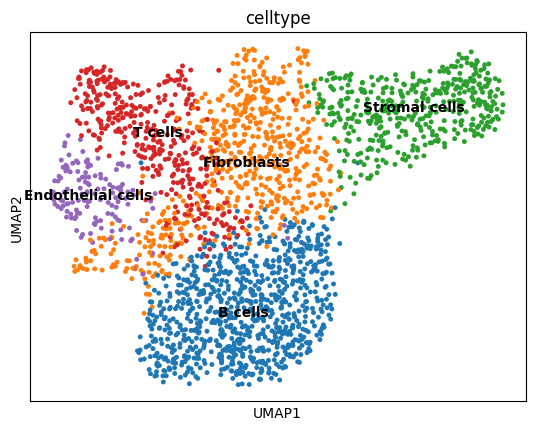

/tmp/ipykernel_2580752/4273625509.py:85: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=["celltype"], spot_size=20)


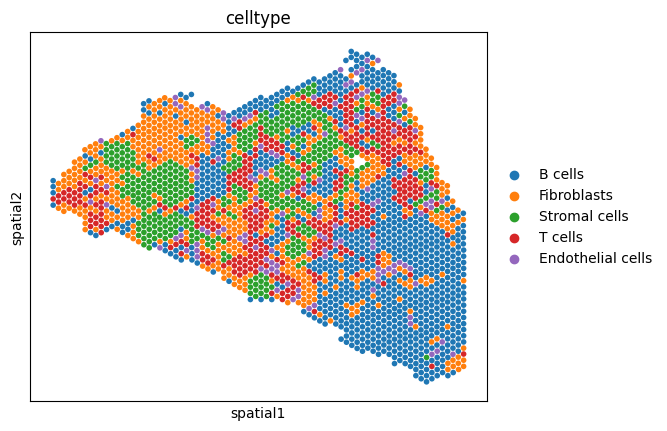

In [11]:
import os
import pandas as pd
import scanpy as sc
import anndata as ad
from PIL import Image
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.image as mpimg
base_dir = "./STimage-1K4M/breast"
sample_name = "GSE203612_GSM6177599"
coord_path = os.path.join(base_dir, "coord", f"{sample_name}_coord.csv")
gene_path  = os.path.join(base_dir, "gene_exp", f"{sample_name}_count.csv")
img_path   = os.path.join(base_dir, "image", f"{sample_name}.png")
save_path = f"./database/{sample_name}/{sample_name}.npz"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
# ---- 1. 读取 CSV ----
count_df = pd.read_csv(gene_path, index_col=0)
coord_df = pd.read_csv(coord_path, index_col=0)

# ---- 1.5 鼠类 → 转人类基因 ----
count_df = preprocess_gene_matrix(count_df)
if count_df is None or count_df.shape[1] == 0:
    raise ValueError(f"无法映射任何基因，样本 {sample_name} 无法处理")

# ---- 2. 构造 AnnData ----
adata = ad.AnnData(
    X = count_df.values,
    obs = pd.DataFrame(index = count_df.index),
    var = pd.DataFrame(index = count_df.columns)
)
adata.obsm["spatial"] = coord_df.loc[adata.obs.index, ["xaxis", "yaxis"]].values

# ---- 3. 标准预处理 ----
sc.pp.filter_cells(adata, min_genes=50)
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# ---- 4. 可选：生成 tokens (如果你还想用 token) ----
tokens = tokenize_spots(
    ad_ge=adata,
    top_k=2048,
    label_mode="threshold",
    valid_gene_names=valid_genes,
    add_labels=False
)

# ---- 5. 聚类和降维 ----
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var.highly_variable]

sc.pp.scale(adata)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)
sc.tl.leiden(adata, resolution=0.5)  # cluster 注释

# ---- 6. 可视化 UMAP ----
sc.tl.umap(adata)
sc.pl.umap(adata, color=['leiden'], title=f"{sample_name} clusters")

# ---- 7. 找 marker 基因 ----
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)  # 显示每个 cluster 前10 marker 基因

# ---- 8. 可视化空间图 ----
sc.pl.spatial(adata, color='leiden', spot_size=20, title=f"{sample_name} spatial clusters")

# ---- 9. 输出每个 cluster 的 top marker 基因 ----
marker_df_all = sc.get.rank_genes_groups_df(adata, group=None)
for g in marker_df_all['group'].unique():
    print(f"=== Cluster {g} ===")
    print(marker_df_all[marker_df_all['group']==g].head(10))

cluster_to_celltype = {
    "0": "B cells", 
    "1": "Fibroblasts",
    "2": "Stromal cells", 
    "3": "T cells", 
    "4": "Endothelial cells"
}

adata.obs["celltype"] = adata.obs["leiden"].map(cluster_to_celltype)

sc.pl.umap(adata, color=["celltype"], legend_loc="on data")
sc.pl.spatial(adata, color=["celltype"], spot_size=20)


# ---- 提取 patch ----
patches = extract_spot_patches_exact32(adata, img_path)

# ---- 保存 npz ----
spot_ids = adata.obs.index.values
spot_types = adata.obs["celltype"].values
coords = adata.obsm["spatial"]

np.savez_compressed(
    save_path,
    patch=patches,
    tokens=np.array(tokens, dtype=object),
    spot_ids=spot_ids,
    spot_types=spot_types,
    coords=coords,
)